# Project - Machine Learning

# Problem 1:
# You are hired by one of the leading news channel CNBE who wants to analyze recent elections. This survey was conducted on 1525 voters with 9 variables. You have to build a model, to predict which party a voter will vote for on the basis of the given information, to create an exit poll that will help in predicting overall win and seats covered by a particular party.

# Dataset for Problem: Election_Data.xlsx

In [1]:
!pip install xgboost

You are using pip version 9.0.1, however version 20.2 is available.
You should consider upgrading via the 'python -m pip install --upgrade pip' command.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from scipy.stats import zscore
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn import svm
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
import xgboost as xgb
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import roc_auc_score, roc_curve, classification_report, confusion_matrix, accuracy_score

## Data Ingestion:

## 1. Read the dataset. Do the descriptive statistics and do null value condition check. Write an inference on it.

## Ans:

In [154]:
df1 = pd.read_excel('Election_Data.xlsx', 'Election_Dataset_Two Classes')

In [26]:
df1.head()

,Unnamed: 0,vote,age,economic.cond.national,economic.cond.household,Blair,Hague,Europe,political.knowledge,gender
0,1,Labour,43,3,3,4,1,2,2,female
1,2,Labour,36,4,4,4,4,5,2,male
2,3,Labour,35,4,4,5,2,3,2,male
3,4,Labour,24,4,2,2,1,4,0,female
4,5,Labour,41,2,2,1,1,6,2,male


In [27]:
df1.shape

(1525, 10)

In [28]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1525 entries, 0 to 1524
Data columns (total 10 columns):
Unnamed: 0                 1525 non-null int64
vote                       1525 non-null object
age                        1525 non-null int64
economic.cond.national     1525 non-null int64
economic.cond.household    1525 non-null int64
Blair                      1525 non-null int64
Hague                      1525 non-null int64
Europe                     1525 non-null int64
political.knowledge        1525 non-null int64
gender                     1525 non-null object
dtypes: int64(8), object(2)
memory usage: 119.2+ KB


In [29]:
df1.describe(include='all')

,Unnamed: 0,vote,age,economic.cond.national,economic.cond.household,Blair,Hague,Europe,political.knowledge,gender
count,1525.000000,1525,1525.000000,1525.000000,1525.000000,1525.000000,1525.000000,1525.000000,1525.000000,1525
unique,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
top,NaN,Labour,NaN,NaN,NaN,NaN,NaN,NaN,NaN,female
freq,NaN,1063,NaN,NaN,NaN,NaN,NaN,NaN,NaN,812
mean,763.000000,NaN,54.182295,3.245902,3.140328,3.334426,2.746885,6.728525,1.542295,NaN
std,440.373894,NaN,15.711209,0.880969,0.929951,1.174824,1.230703,3.297538,1.083315,NaN
min,1.000000,NaN,24.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,NaN
25%,382.000000,NaN,41.000000,3.000000,3.000000,2.000000,2.000000,4.000000,0.000000,NaN
50%,763.000000,NaN,53.000000,3.000000,3.000000,4.000000,2.000000,6.000000,2.000000,NaN
75%,1144.000000,NaN,67.000000,4.000000,4.000000,4.000000,4.000000,10.000000,2.000000,NaN


In [30]:
df1.isna().sum()

Unnamed: 0                 0
vote                       0
age                        0
economic.cond.national     0
economic.cond.household    0
Blair                      0
Hague                      0
Europe                     0
political.knowledge        0
gender                     0
dtype: int64

In [31]:
dups = df1.duplicated().sum()
dups

0

In [32]:
df1.dtypes

Unnamed: 0                  int64
vote                       object
age                         int64
economic.cond.national      int64
economic.cond.household     int64
Blair                       int64
Hague                       int64
Europe                      int64
political.knowledge         int64
gender                     object
dtype: object

In [33]:
df1.quantile(0.75)-df1.quantile(0.25)

Unnamed: 0                 762.0
age                         26.0
economic.cond.national       1.0
economic.cond.household      1.0
Blair                        2.0
Hague                        2.0
Europe                       6.0
political.knowledge          2.0
dtype: float64

In [34]:
df1.var()

Unnamed: 0                 193929.166667
age                           246.842075
economic.cond.national          0.776107
economic.cond.household         0.864810
Blair                           1.380212
Hague                           1.514631
Europe                         10.873759
political.knowledge             1.173571
dtype: float64

In [35]:
df1.skew()

Unnamed: 0                 0.000000
age                        0.144621
economic.cond.national    -0.240453
economic.cond.household   -0.149552
Blair                     -0.535419
Hague                      0.152100
Europe                    -0.135947
political.knowledge       -0.426838
dtype: float64

## 2. Perform Univariate and Bivariate Analysis. Do exploratory data analysis. Check for Outliers.

## Ans:

### Outlier check using Boxplot

(array([1, 2, 3, 4, 5, 6, 7, 8]), <a list of 8 Text xticklabel objects>)

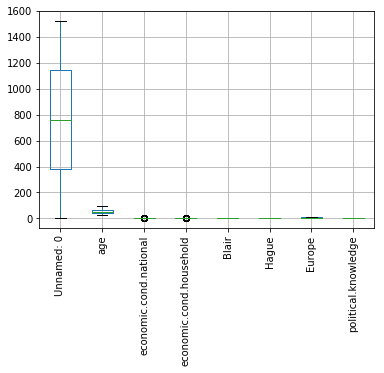

In [36]:
df1.boxplot()
plt.xticks(rotation=90)

### Univariate analysis

array([[<matplotlib.axes._subplots.AxesSubplot object at 0x0000000FEA9C9EB8>,
      dtype=object)

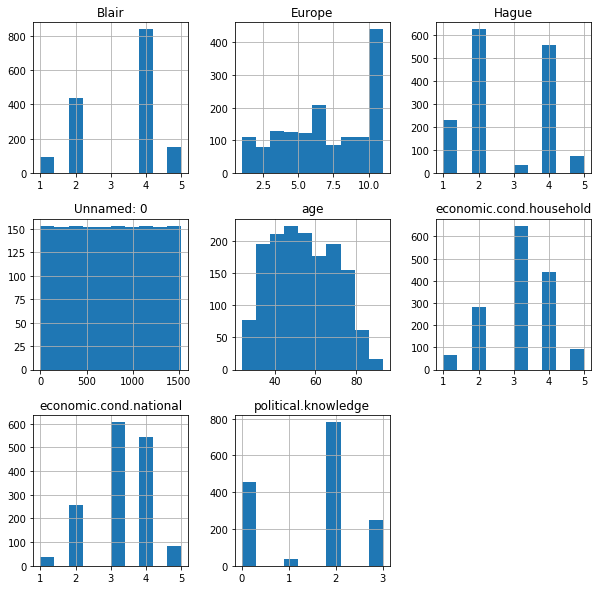

In [37]:
df1.hist(figsize=(10,10))

### Bi-Variate analysis

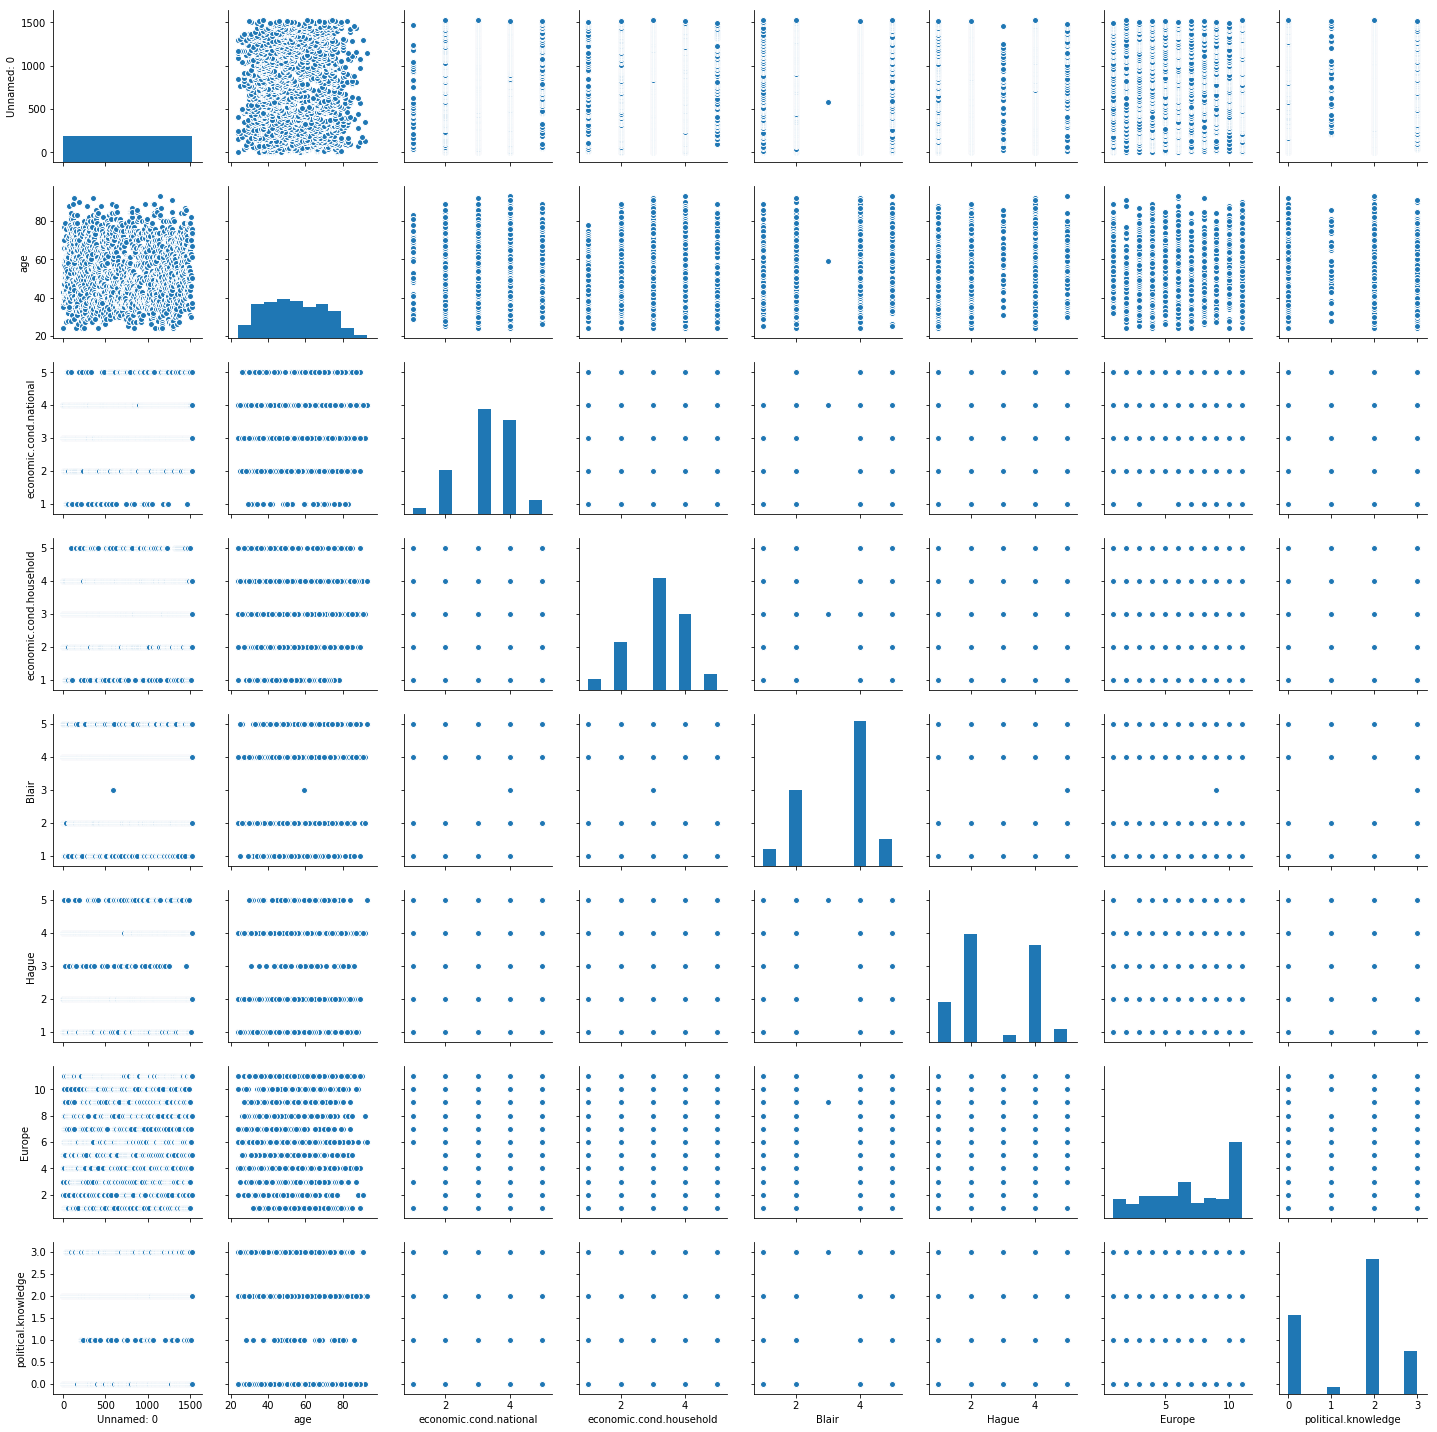

In [38]:
sns.pairplot(df1)

In [39]:
df1.cov()

,Unnamed: 0,age,economic.cond.national,economic.cond.household,Blair,Hague,Europe,political.knowledge
Unnamed: 0,193929.166667,35.476378,27.887139,14.704724,0.828740,0.152887,55.498688,1.185696
age,35.476378,246.842075,0.256981,-0.607619,0.557762,0.669531,3.568550,-0.825301
economic.cond.national,27.887139,0.256981,0.776107,0.283712,0.338314,-0.216589,-0.608397,-0.022546
economic.cond.household,14.704724,-0.607619,0.283712,0.864810,0.235192,-0.116689,-0.352299,-0.038091
Blair,0.828740,0.557762,0.338314,0.235192,1.380212,-0.351648,-1.147341,-0.026621
Hague,0.152887,0.669531,-0.216589,-0.116689,-0.351648,1.514631,1.166149,-0.040469
Europe,55.498688,3.568550,-0.608397,-0.352299,-1.147341,1.166149,10.873759,-0.544285
political.knowledge,1.185696,-0.825301,-0.022546,-0.038091,-0.026621,-0.040469,-0.544285,1.173571


In [40]:
df1.corr()

,Unnamed: 0,age,economic.cond.national,economic.cond.household,Blair,Hague,Europe,political.knowledge
Unnamed: 0,1.000000,0.005128,0.071882,0.035907,0.001602,0.000282,0.038218,0.002485
age,0.005128,1.000000,0.018567,-0.041587,0.030218,0.034626,0.068880,-0.048490
economic.cond.national,0.071882,0.018567,1.000000,0.346303,0.326878,-0.199766,-0.209429,-0.023624
economic.cond.household,0.035907,-0.041587,0.346303,1.000000,0.215273,-0.101956,-0.114885,-0.037810
Blair,0.001602,0.030218,0.326878,0.215273,1.000000,-0.243210,-0.296162,-0.020917
Hague,0.000282,0.034626,-0.199766,-0.101956,-0.243210,1.000000,0.287350,-0.030354
Europe,0.038218,0.068880,-0.209429,-0.114885,-0.296162,0.287350,1.000000,-0.152364
political.knowledge,0.002485,-0.048490,-0.023624,-0.037810,-0.020917,-0.030354,-0.152364,1.000000


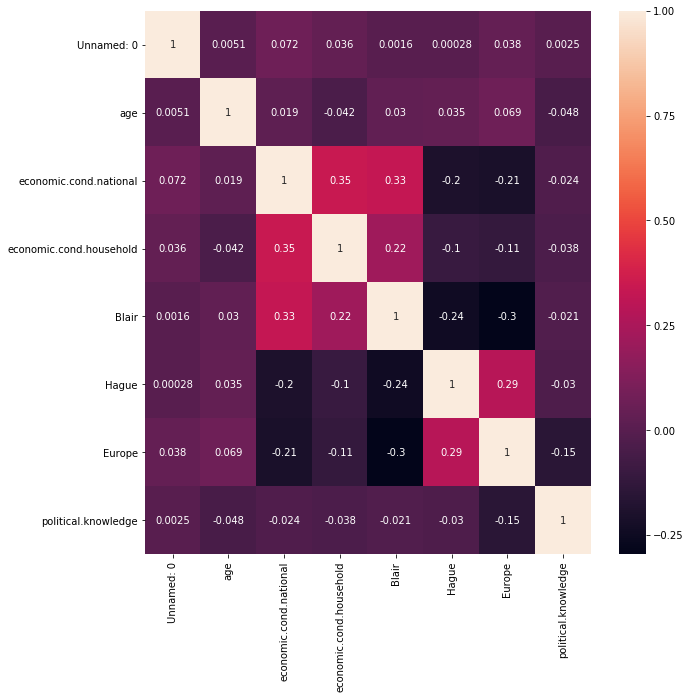

In [41]:
plt.figure(figsize=(10,10))
sns.heatmap(df1.corr(), annot = True)

### From the above heatmap we can see that there is no correlation between the independent variables. Hence we will use all the independent variables for further analysis.

## Data Preparation:

## 1. Encode the data (having string values) for Modelling. Is Scaling necessary here or not? Data Split: Split the data into train and test (70:30).

## Ans:

### Dropping the unwanted variables

In [155]:
df1.drop('Unnamed: 0', axis = 1, inplace = True)

In [156]:
df1.head()

,vote,age,economic.cond.national,economic.cond.household,Blair,Hague,Europe,political.knowledge,gender
0,Labour,43,3,3,4,1,2,2,female
1,Labour,36,4,4,4,4,5,2,male
2,Labour,35,4,4,5,2,3,2,male
3,Labour,24,4,2,2,1,4,0,female
4,Labour,41,2,2,1,1,6,2,male


In [157]:
df1.shape

(1525, 9)

### Split the independent and dependent variables

In [158]:
x = df1.drop('vote', axis = 1)
y = df1.pop('vote')

### Converting dependent variable into Categorical

In [159]:
y = pd.Categorical(y).codes

### Scaling/Normalizing the continuous independent variable

In [160]:
features_to_normalize = ['age']
x[features_to_normalize] = x[features_to_normalize].apply(lambda x:(x-x.min()) / (x.max()-x.min()))

### Coverting independent variable into Object

In [161]:
x[['economic.cond.national','economic.cond.household','Blair','Hague','Europe','political.knowledge','gender']]= (x[['economic.cond.national','economic.cond.household','Blair','Hague','Europe','political.knowledge','gender']]).astype("object")

In [162]:
x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1525 entries, 0 to 1524
Data columns (total 8 columns):
age                        1525 non-null float64
economic.cond.national     1525 non-null object
economic.cond.household    1525 non-null object
Blair                      1525 non-null object
Hague                      1525 non-null object
Europe                     1525 non-null object
political.knowledge        1525 non-null object
gender                     1525 non-null object
dtypes: float64(1), object(7)
memory usage: 95.4+ KB


### Creating dummy variables out of categorical independent variables

In [163]:
x = pd.get_dummies(x, prefix_sep='_', drop_first=True)

In [164]:
x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1525 entries, 0 to 1524
Data columns (total 31 columns):
age                          1525 non-null float64
economic.cond.national_2     1525 non-null uint8
economic.cond.national_3     1525 non-null uint8
economic.cond.national_4     1525 non-null uint8
economic.cond.national_5     1525 non-null uint8
economic.cond.household_2    1525 non-null uint8
economic.cond.household_3    1525 non-null uint8
economic.cond.household_4    1525 non-null uint8
economic.cond.household_5    1525 non-null uint8
Blair_2                      1525 non-null uint8
Blair_3                      1525 non-null uint8
Blair_4                      1525 non-null uint8
Blair_5                      1525 non-null uint8
Hague_2                      1525 non-null uint8
Hague_3                      1525 non-null uint8
Hague_4                      1525 non-null uint8
Hague_5                      1525 non-null uint8
Europe_2                     1525 non-null uint8
Europe_3 

In [165]:
x.head()

,age,economic.cond.national_2,economic.cond.national_3,economic.cond.national_4,economic.cond.national_5,economic.cond.household_2,economic.cond.household_3,economic.cond.household_4,economic.cond.household_5,Blair_2,...,Europe_6,Europe_7,Europe_8,Europe_9,Europe_10,Europe_11,political.knowledge_1,political.knowledge_2,political.knowledge_3,gender_male
0,0.275362,0,1,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,1,0,0
1,0.173913,0,0,1,0,0,0,1,0,0,...,0,0,0,0,0,0,0,1,0,1
2,0.159420,0,0,1,0,0,0,1,0,0,...,0,0,0,0,0,0,0,1,0,1
3,0.000000,0,0,1,0,1,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
4,0.246377,1,0,0,0,1,0,0,0,0,...,1,0,0,0,0,0,0,1,0,1


### Split the data to Train-Test(70:30)

In [166]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=.30, random_state=0)

In [167]:
print('X_train',X_train.shape)
print('X_test',X_test.shape)
print('y_train',y_train.shape)
print('y_test',y_test.shape)

X_train (1067, 31)
X_test (458, 31)
y_train (1067,)
y_test (458,)


## Modelling:

## 1. Apply Logistic Regression and LDA (linear discriminant analysis).

### Logistic Regression

In [168]:
Logit_model = LogisticRegression()
Logit_model.fit(X_train, y_train)

LogisticRegression()

In [169]:
y_train_predict_logit = Logit_model.predict(X_train)
y_test_predict_logit = Logit_model.predict(X_test)

### Linear Discriminant Analysis

In [174]:
LDA_model = LinearDiscriminantAnalysis()
LDA_model.fit(X_train, y_train)

LinearDiscriminantAnalysis()

In [175]:
y_train_predict_LDA = LDA_model.predict(X_train)
y_test_predict_LDA = LDA_model.predict(X_test)

## 2. Apply KNN Model, Naïve Bayes Model and support vector machine (SVM) model. Interpret the results.

### KNN

In [176]:
KNN_model = KNeighborsClassifier()
KNN_model.fit(X_train, y_train)

KNeighborsClassifier()

In [177]:
y_train_predict_KNN = KNN_model.predict(X_train)
y_test_predict_KNN = KNN_model.predict(X_test)

### Naive Bayes

In [178]:
NB_model = GaussianNB()
NB_model.fit(X_train, y_train)

GaussianNB()

In [179]:
y_train_predict_NB = NB_model.predict(X_train)
y_test_predict_NB = NB_model.predict(X_test)

### Support Vector Machine

In [218]:
SVM_model = svm.SVC(probability=True)
SVM_model.fit(X_train, y_train)

SVC(probability=True)

In [219]:
y_train_predict_SVM = SVM_model.predict(X_train)
y_test_predict_SVM = SVM_model.predict(X_test)

## 3. Model Tuning, Bagging (Random Forest should be applied for Bagging) and Boosting.

### Bagging (Random Forest) with Tuning parameters

In [182]:
param_grid_RFCL = {
    'max_depth': [8,10,12],
    'max_features': [12,18,24],
    'min_samples_leaf': [50,100,150],
    'min_samples_split': [150,300,450],
    'n_estimators': [300,500]
}

RF_model = RandomForestClassifier()

grid_search_RFCL = GridSearchCV(estimator = RF_model, param_grid = param_grid_RFCL, cv = 5)

In [183]:
grid_search_RFCL.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(),
             param_grid={'max_depth': [8, 10, 12], 'max_features': [12, 18, 24],
                         'min_samples_leaf': [50, 100, 150],
                         'min_samples_split': [150, 300, 450],
                         'n_estimators': [300, 500]})

In [184]:
grid_search_RFCL.best_params_

{'max_depth': 8,
 'max_features': 12,
 'min_samples_leaf': 50,
 'min_samples_split': 150,
 'n_estimators': 500}

In [185]:
best_grid_RFCL = grid_search_RFCL.best_estimator_

In [186]:
best_grid_RFCL

RandomForestClassifier(max_depth=8, max_features=12, min_samples_leaf=50,
                       min_samples_split=150, n_estimators=500)

In [187]:
y_train_predict_RFCL = best_grid_RFCL.predict(X_train)
y_test_predict_RFCL = best_grid_RFCL.predict(X_test)

### Boosting with Tuning parameters

### XGBoost

In [188]:
XGB_model=xgb.XGBClassifier(random_state=1,learning_rate=0.01)
XGB_model.fit(X_train, y_train)

XGBClassifier(base_score=0.5, booster='gbtree', colsample_bylevel=1,
              colsample_bynode=1, colsample_bytree=1, gamma=0, gpu_id=-1,
              importance_type='gain', interaction_constraints='',
              learning_rate=0.01, max_delta_step=0, max_depth=6,
              min_child_weight=1, missing=nan, monotone_constraints='()',
              n_estimators=100, n_jobs=0, num_parallel_tree=1, random_state=1,
              reg_alpha=0, reg_lambda=1, scale_pos_weight=1, subsample=1,
              tree_method='exact', validate_parameters=1, verbosity=None)

In [189]:
y_train_predict_XGB = XGB_model.predict(X_train)
y_test_predict_XGB = XGB_model.predict(X_test)

### ADA Boost

In [190]:
ADB_model = AdaBoostClassifier(n_estimators=100,random_state=1)
ADB_model.fit(X_train,y_train)

AdaBoostClassifier(n_estimators=100, random_state=1)

In [191]:
y_train_predict_ADB = ADB_model.predict(X_train)
y_test_predict_ADB = ADB_model.predict(X_test)

## 4. Performance Metrics: Check the performance of Predictions on Train and Test sets using Accuracy, Confusion Matrix, Plot ROC curve and get ROC_AUC score for each model. Final Model: Compare the models and write inference which model is best/optimized.

### Performance Metrics for Logistic Regression:

In [192]:
print(accuracy_score(y_train, y_train_predict_logit))
print(accuracy_score(y_test, y_test_predict_logit)) 
print(confusion_matrix(y_train, y_train_predict_logit)) 
print(confusion_matrix(y_test, y_test_predict_logit)) 
print(classification_report(y_train, y_train_predict_logit))
print(classification_report(y_test, y_test_predict_logit))
print(roc_auc_score(y_train, Logit_model.predict_proba(X_train)[:,1]))
print(roc_auc_score(y_test, Logit_model.predict_proba(X_test)[:,1]))

0.851921274601687
0.8231441048034934
[[231  97]
 [ 61 678]]
[[ 90  44]
 [ 37 287]]
              precision    recall  f1-score   support

           0       0.79      0.70      0.75       328
           1       0.87      0.92      0.90       739

    accuracy                           0.85      1067
   macro avg       0.83      0.81      0.82      1067
weighted avg       0.85      0.85      0.85      1067

              precision    recall  f1-score   support

           0       0.71      0.67      0.69       134
           1       0.87      0.89      0.88       324

    accuracy                           0.82       458
   macro avg       0.79      0.78      0.78       458
weighted avg       0.82      0.82      0.82       458

0.9022946301858148
0.8813916528468767


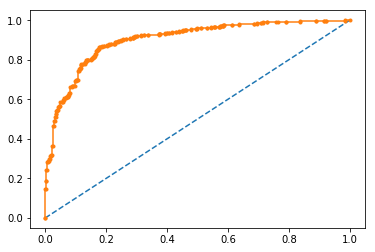

In [193]:
fpr_log_reg_train, tpr_log_reg_train, tresholds_log_reg_train = roc_curve(y_train, Logit_model.predict_proba(X_train)[:,1]) 
plt.plot([0,1], [0,1], linestyle='--') 
plt.plot(fpr_log_reg_train, tpr_log_reg_train, marker='.')

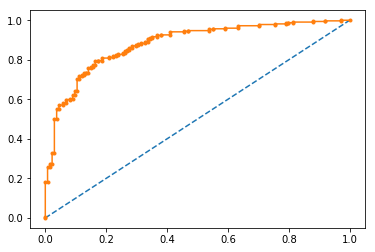

In [194]:
fpr_log_reg_test, tpr_log_reg_test, tresholds_log_reg_test = roc_curve(y_test, Logit_model.predict_proba(X_test)[:,1]) 
plt.plot([0,1], [0,1], linestyle='--') 
plt.plot(fpr_log_reg_test, tpr_log_reg_test, marker='.')

### Performance Metrics for Linear Discriminant Analysis:

In [195]:
print(accuracy_score(y_train, y_train_predict_LDA))
print(accuracy_score(y_test, y_test_predict_LDA)) 
print(confusion_matrix(y_train, y_train_predict_LDA)) 
print(confusion_matrix(y_test, y_test_predict_LDA)) 
print(classification_report(y_train, y_train_predict_LDA))
print(classification_report(y_test, y_test_predict_LDA))
print(roc_auc_score(y_train, LDA_model.predict_proba(X_train)[:,1]))
print(roc_auc_score(y_test, LDA_model.predict_proba(X_test)[:,1]))

0.8472352389878163
0.8253275109170306
[[233  95]
 [ 68 671]]
[[ 94  40]
 [ 40 284]]
              precision    recall  f1-score   support

           0       0.77      0.71      0.74       328
           1       0.88      0.91      0.89       739

    accuracy                           0.85      1067
   macro avg       0.83      0.81      0.82      1067
weighted avg       0.84      0.85      0.85      1067

              precision    recall  f1-score   support

           0       0.70      0.70      0.70       134
           1       0.88      0.88      0.88       324

    accuracy                           0.83       458
   macro avg       0.79      0.79      0.79       458
weighted avg       0.83      0.83      0.83       458

0.9016056635532528
0.8782822001105582


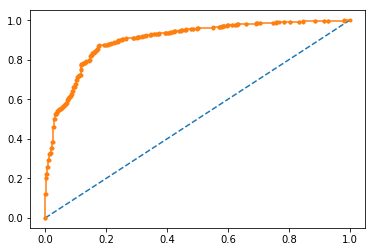

In [196]:
fpr_LDA_train, tpr_LDA_train, tresholds_LDA_train = roc_curve(y_train, LDA_model.predict_proba(X_train)[:,1]) 
plt.plot([0,1], [0,1], linestyle='--') 
plt.plot(fpr_LDA_train, tpr_LDA_train, marker='.')

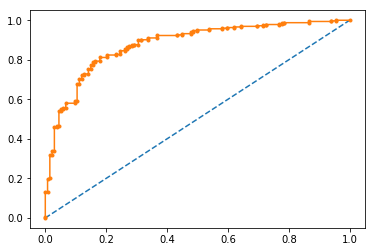

In [197]:
fpr_LDA_test, tpr_LDA_test, tresholds_LDA_test = roc_curve(y_test, LDA_model.predict_proba(X_test)[:,1]) 
plt.plot([0,1], [0,1], linestyle='--') 
plt.plot(fpr_LDA_test, tpr_LDA_test, marker='.')

### Performance Metrics for KNN:

In [198]:
print(accuracy_score(y_train, y_train_predict_KNN))
print(accuracy_score(y_test, y_test_predict_KNN)) 
print(confusion_matrix(y_train, y_train_predict_KNN)) 
print(confusion_matrix(y_test, y_test_predict_KNN)) 
print(classification_report(y_train, y_train_predict_KNN))
print(classification_report(y_test, y_test_predict_KNN))
print(roc_auc_score(y_train, KNN_model.predict_proba(X_train)[:,1]))
print(roc_auc_score(y_test, KNN_model.predict_proba(X_test)[:,1]))

0.8566073102155577
0.8034934497816594
[[235  93]
 [ 60 679]]
[[ 89  45]
 [ 45 279]]
              precision    recall  f1-score   support

           0       0.80      0.72      0.75       328
           1       0.88      0.92      0.90       739

    accuracy                           0.86      1067
   macro avg       0.84      0.82      0.83      1067
weighted avg       0.85      0.86      0.85      1067

              precision    recall  f1-score   support

           0       0.66      0.66      0.66       134
           1       0.86      0.86      0.86       324

    accuracy                           0.80       458
   macro avg       0.76      0.76      0.76       458
weighted avg       0.80      0.80      0.80       458

0.9236340308260998
0.8496406854615809


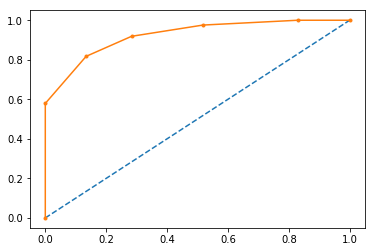

In [199]:
fpr_KNN_train, tpr_KNN_train, tresholds_KNN_train = roc_curve(y_train, KNN_model.predict_proba(X_train)[:,1]) 
plt.plot([0,1], [0,1], linestyle='--') 
plt.plot(fpr_KNN_train, tpr_KNN_train, marker='.')

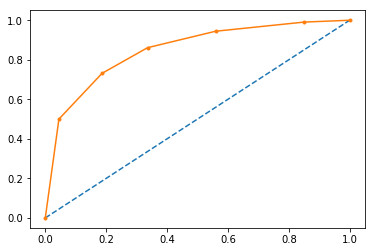

In [200]:
fpr_KNN_test, tpr_KNN_test, tresholds_KNN_test = roc_curve(y_test, KNN_model.predict_proba(X_test)[:,1]) 
plt.plot([0,1], [0,1], linestyle='--') 
plt.plot(fpr_KNN_test, tpr_KNN_test, marker='.')

### Performance Metrics for Naive Bayes:

In [201]:
print(accuracy_score(y_train, y_train_predict_NB))
print(accuracy_score(y_test, y_test_predict_NB)) 
print(confusion_matrix(y_train, y_train_predict_NB)) 
print(confusion_matrix(y_test, y_test_predict_NB)) 
print(classification_report(y_train, y_train_predict_NB))
print(classification_report(y_test, y_test_predict_NB))
print(roc_auc_score(y_train, NB_model.predict_proba(X_train)[:,1]))
print(roc_auc_score(y_test, NB_model.predict_proba(X_test)[:,1]))

0.7853795688847235
0.7794759825327511
[[131 197]
 [ 32 707]]
[[ 49  85]
 [ 16 308]]
              precision    recall  f1-score   support

           0       0.80      0.40      0.53       328
           1       0.78      0.96      0.86       739

    accuracy                           0.79      1067
   macro avg       0.79      0.68      0.70      1067
weighted avg       0.79      0.79      0.76      1067

              precision    recall  f1-score   support

           0       0.75      0.37      0.49       134
           1       0.78      0.95      0.86       324

    accuracy                           0.78       458
   macro avg       0.77      0.66      0.68       458
weighted avg       0.77      0.78      0.75       458

0.8451660945905806
0.822312050856827


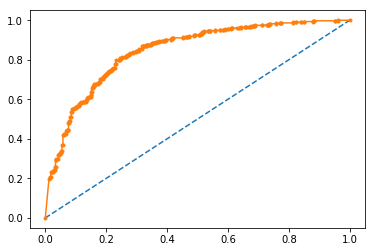

In [202]:
fpr_NB_train, tpr_NB_train, tresholds_NB_train = roc_curve(y_train, NB_model.predict_proba(X_train)[:,1]) 
plt.plot([0,1], [0,1], linestyle='--') 
plt.plot(fpr_NB_train, tpr_NB_train, marker='.')

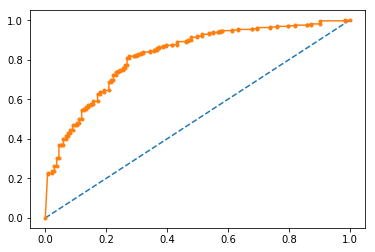

In [203]:
fpr_NB_test, tpr_NB_test, tresholds_NB_test = roc_curve(y_test, NB_model.predict_proba(X_test)[:,1]) 
plt.plot([0,1], [0,1], linestyle='--') 
plt.plot(fpr_NB_test, tpr_NB_test, marker='.')

### Performance Metrics for SVM:

In [220]:
print(accuracy_score(y_train, y_train_predict_SVM))
print(accuracy_score(y_test, y_test_predict_SVM)) 
print(confusion_matrix(y_train, y_train_predict_SVM)) 
print(confusion_matrix(y_test, y_test_predict_SVM)) 
print(classification_report(y_train, y_train_predict_SVM))
print(classification_report(y_test, y_test_predict_SVM))
print(roc_auc_score(y_train, SVM_model.predict_proba(X_train)[:,1]))
print(roc_auc_score(y_test, SVM_model.predict_proba(X_test)[:,1]))

0.8884723523898782
0.834061135371179
[[247  81]
 [ 38 701]]
[[ 93  41]
 [ 35 289]]
              precision    recall  f1-score   support

           0       0.87      0.75      0.81       328
           1       0.90      0.95      0.92       739

    accuracy                           0.89      1067
   macro avg       0.88      0.85      0.86      1067
weighted avg       0.89      0.89      0.89      1067

              precision    recall  f1-score   support

           0       0.73      0.69      0.71       134
           1       0.88      0.89      0.88       324

    accuracy                           0.83       458
   macro avg       0.80      0.79      0.80       458
weighted avg       0.83      0.83      0.83       458

0.9463884946697911
0.8682858853878755


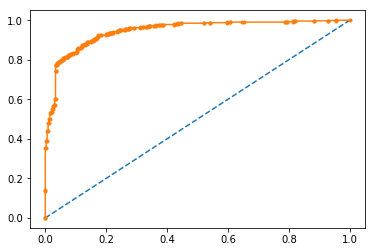

In [221]:
fpr_SVM_train, tpr_SVM_train, tresholds_SVM_train = roc_curve(y_train, SVM_model.predict_proba(X_train)[:,1]) 
plt.plot([0,1], [0,1], linestyle='--') 
plt.plot(fpr_SVM_train, tpr_SVM_train, marker='.')

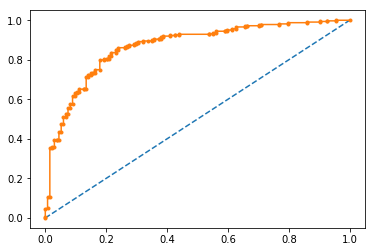

In [222]:
fpr_SVM_test, tpr_SVM_test, tresholds_SVM_test = roc_curve(y_test, SVM_model.predict_proba(X_test)[:,1]) 
plt.plot([0,1], [0,1], linestyle='--') 
plt.plot(fpr_SVM_test, tpr_SVM_test, marker='.')

### Performance Metrics for Random Forest:

In [207]:
print(accuracy_score(y_train, y_train_predict_RFCL))
print(accuracy_score(y_test, y_test_predict_RFCL)) 
print(confusion_matrix(y_train, y_train_predict_RFCL)) 
print(confusion_matrix(y_test, y_test_predict_RFCL)) 
print(classification_report(y_train, y_train_predict_RFCL))
print(classification_report(y_test, y_test_predict_RFCL))
print(roc_auc_score(y_train, best_grid_RFCL.predict_proba(X_train)[:,1]))
print(roc_auc_score(y_test, best_grid_RFCL.predict_proba(X_test)[:,1]))

0.7694470477975632
0.759825327510917
[[124 204]
 [ 42 697]]
[[ 42  92]
 [ 18 306]]
              precision    recall  f1-score   support

           0       0.75      0.38      0.50       328
           1       0.77      0.94      0.85       739

    accuracy                           0.77      1067
   macro avg       0.76      0.66      0.68      1067
weighted avg       0.77      0.77      0.74      1067

              precision    recall  f1-score   support

           0       0.70      0.31      0.43       134
           1       0.77      0.94      0.85       324

    accuracy                           0.76       458
   macro avg       0.73      0.63      0.64       458
weighted avg       0.75      0.76      0.73       458

0.8351595762236378
0.820169983416252


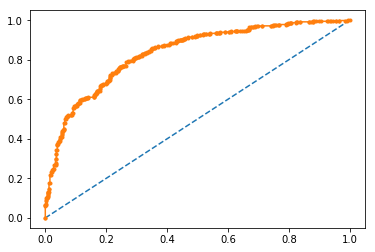

In [208]:
fpr_RFCL_train, tpr_RFCL_train, tresholds_RFCL_train = roc_curve(y_train, best_grid_RFCL.predict_proba(X_train)[:,1]) 
plt.plot([0,1], [0,1], linestyle='--') 
plt.plot(fpr_RFCL_train, tpr_RFCL_train, marker='.')

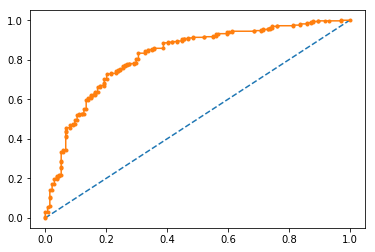

In [209]:
fpr_RFCL_test, tpr_RFCL_test, tresholds_RFCL_test = roc_curve(y_test, best_grid_RFCL.predict_proba(X_test)[:,1]) 
plt.plot([0,1], [0,1], linestyle='--') 
plt.plot(fpr_RFCL_test, tpr_RFCL_test, marker='.')

### Performance Metrics for XG Boost:

In [210]:
print(accuracy_score(y_train, y_train_predict_XGB))
print(accuracy_score(y_test, y_test_predict_XGB)) 
print(confusion_matrix(y_train, y_train_predict_XGB)) 
print(confusion_matrix(y_test, y_test_predict_XGB)) 
print(classification_report(y_train, y_train_predict_XGB))
print(classification_report(y_test, y_test_predict_XGB))
print(roc_auc_score(y_train, XGB_model.predict_proba(X_train)[:,1]))
print(roc_auc_score(y_test, XGB_model.predict_proba(X_test)[:,1]))

0.8687910028116214
0.8165938864628821
[[238  90]
 [ 50 689]]
[[ 90  44]
 [ 40 284]]
              precision    recall  f1-score   support

           0       0.83      0.73      0.77       328
           1       0.88      0.93      0.91       739

    accuracy                           0.87      1067
   macro avg       0.86      0.83      0.84      1067
weighted avg       0.87      0.87      0.87      1067

              precision    recall  f1-score   support

           0       0.69      0.67      0.68       134
           1       0.87      0.88      0.87       324

    accuracy                           0.82       458
   macro avg       0.78      0.77      0.78       458
weighted avg       0.82      0.82      0.82       458

0.9223901778936598
0.8448267919660954


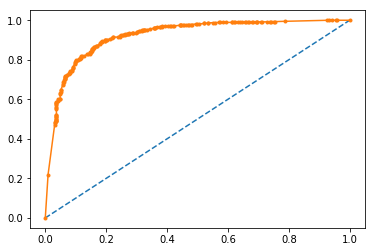

In [211]:
fpr_XGB_train, tpr_XGB_train, tresholds_XGB_train = roc_curve(y_train, XGB_model.predict_proba(X_train)[:,1]) 
plt.plot([0,1], [0,1], linestyle='--') 
plt.plot(fpr_XGB_train, tpr_XGB_train, marker='.')

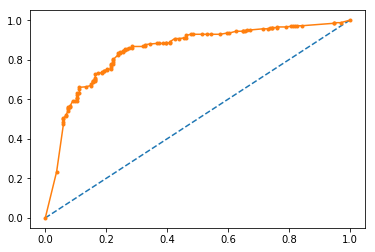

In [212]:
fpr_XGB_test, tpr_XGB_test, tresholds_XGB_test = roc_curve(y_test, XGB_model.predict_proba(X_test)[:,1]) 
plt.plot([0,1], [0,1], linestyle='--') 
plt.plot(fpr_XGB_test, tpr_XGB_test, marker='.')

### Performance Metrics for ADA Boost:

In [213]:
print(accuracy_score(y_train, y_train_predict_ADB))
print(accuracy_score(y_test, y_test_predict_ADB)) 
print(confusion_matrix(y_train, y_train_predict_ADB)) 
print(confusion_matrix(y_test, y_test_predict_ADB)) 
print(classification_report(y_train, y_train_predict_ADB))
print(classification_report(y_test, y_test_predict_ADB))
print(roc_auc_score(y_train, ADB_model.predict_proba(X_train)[:,1]))
print(roc_auc_score(y_test, ADB_model.predict_proba(X_test)[:,1]))

0.8509840674789129
0.8318777292576419
[[233  95]
 [ 64 675]]
[[ 92  42]
 [ 35 289]]
              precision    recall  f1-score   support

           0       0.78      0.71      0.75       328
           1       0.88      0.91      0.89       739

    accuracy                           0.85      1067
   macro avg       0.83      0.81      0.82      1067
weighted avg       0.85      0.85      0.85      1067

              precision    recall  f1-score   support

           0       0.72      0.69      0.70       134
           1       0.87      0.89      0.88       324

    accuracy                           0.83       458
   macro avg       0.80      0.79      0.79       458
weighted avg       0.83      0.83      0.83       458

0.9113172051882901
0.8861825133591301


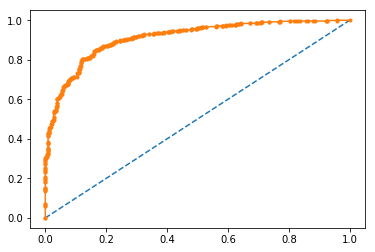

In [214]:
fpr_ADB_train, tpr_ADB_train, tresholds_ADB_train = roc_curve(y_train, ADB_model.predict_proba(X_train)[:,1]) 
plt.plot([0,1], [0,1], linestyle='--') 
plt.plot(fpr_ADB_train, tpr_ADB_train, marker='.')

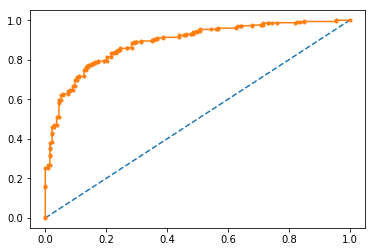

In [215]:
fpr_ADB_test, tpr_ADB_test, tresholds_ADB_test = roc_curve(y_test, ADB_model.predict_proba(X_test)[:,1]) 
plt.plot([0,1], [0,1], linestyle='--') 
plt.plot(fpr_ADB_test, tpr_ADB_test, marker='.')

## Inference:

## 1. Based on these predictions, what are the insights?

### From the above output, we can see that all the models are performing in a similar manner.
### We can see that SVM, ADABoost and XGBoost in respective order are performing much better compared to other models with respect to accuracy score(range of 86-88% for train data and range of 81-83% for test data).
### We can note that Logistic Regression, LDA, KNN are performing in similar manner considering accuracy score(range of 80-85% for train data and range of 80-82% for test data)
### We can also observe that, Naive Bayes and Random Forest in respective order shows a lower performance compared to other models with accuracy score as a key parameter(range of 76-78% for train data and range of 75-77% for test data).
### In general, we can see that the recalls for Labor are on higher side compared to the recalls for conservative.
### We can note that Random Forest and Naive Bayes have a very low re-call around 30-40% for the conservative and a high re-call around 90% for the labor.

# Problem 2:

# In this particular project, we are going to work on the inaugural corpora from the nltk in Python. We will be looking at the following speeches of the Presidents of the United States of America:
# President Franklin D. Roosevelt in 1941
# President John F. Kennedy in 1961
# President Richard Nixon in 1973

# Code Snippet to extract the three speeches:

In [3]:
import nltk
nltk.download('inaugural')
from nltk.corpus import inaugural
inaugural.fileids()
speech1 = inaugural.raw('1941-Roosevelt.txt')
speech2 = inaugural.raw('1961-Kennedy.txt')
speech3 = inaugural.raw('1973-Nixon.txt')

[nltk_data] Downloading package inaugural to
[nltk_data]     C:\Users\arigilasrinivas\AppData\Roaming\nltk_data...
[nltk_data]   Package inaugural is already up-to-date!


In [67]:
import re

## 1) Find the number of characters, words and sentences for the mentioned documents.

## Ans:

### Creating a dataframe of the 3 speechs

In [46]:
y = pd.DataFrame({'President':['Franklin D. Roosevelt','John F. Kennedy','Richard Nixon'], 'Text': [speech1, speech2, speech3]})

In [47]:
y

,President,Text
0,Franklin D. Roosevelt,On each national day of inauguration since 178...
1,John F. Kennedy,"Vice President Johnson, Mr. Speaker, Mr. Chief..."
2,Richard Nixon,"Mr. Vice President, Mr. Speaker, Mr. Chief Jus..."


### Performing Character count

In [48]:
y['char_count'] = y['Text'].str.len()
y

,President,Text,char_count
0,Franklin D. Roosevelt,On each national day of inauguration since 178...,7571
1,John F. Kennedy,"Vice President Johnson, Mr. Speaker, Mr. Chief...",7618
2,Richard Nixon,"Mr. Vice President, Mr. Speaker, Mr. Chief Jus...",9991


### Performing Word count

In [49]:
y['word_count'] = y['Text'].apply(lambda x: len(str(x).split()))
y

,President,Text,char_count,word_count
0,Franklin D. Roosevelt,On each national day of inauguration since 178...,7571,1360
1,John F. Kennedy,"Vice President Johnson, Mr. Speaker, Mr. Chief...",7618,1390
2,Richard Nixon,"Mr. Vice President, Mr. Speaker, Mr. Chief Jus...",9991,1819


### Performing Sentence count

In [50]:
y['sentence_count'] = y['Text'].apply(lambda x: len([x for x in x.split() if x.endswith('.')]))
y

,President,Text,char_count,word_count,sentence_count
0,Franklin D. Roosevelt,On each national day of inauguration since 178...,7571,1360,67
1,John F. Kennedy,"Vice President Johnson, Mr. Speaker, Mr. Chief...",7618,1390,52
2,Richard Nixon,"Mr. Vice President, Mr. Speaker, Mr. Chief Jus...",9991,1819,68


## 2) Remove all the stopwords from all the three speeches.

## Ans:

### Download stopwords

In [51]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\arigilasrinivas\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

### Convert to Lower case text

In [52]:
y['Processed_Text'] = y['Text'].apply(lambda x: " ".join(x.lower() for x in x.split()))

In [53]:
y

,President,Text,char_count,word_count,sentence_count,Processed_Text
0,Franklin D. Roosevelt,On each national day of inauguration since 178...,7571,1360,67,on each national day of inauguration since 178...
1,John F. Kennedy,"Vice President Johnson, Mr. Speaker, Mr. Chief...",7618,1390,52,"vice president johnson, mr. speaker, mr. chief..."
2,Richard Nixon,"Mr. Vice President, Mr. Speaker, Mr. Chief Jus...",9991,1819,68,"mr. vice president, mr. speaker, mr. chief jus..."


### Count the number of Stopwords initially, i.e., Stopwords before

In [54]:
from nltk.corpus import stopwords
stop = stopwords.words('english')

y['stopwords_before'] = y['Processed_Text'].apply(lambda x: len([x for x in x.split() if x in stop]))
y

,President,Text,char_count,word_count,sentence_count,Processed_Text,stopwords_before
0,Franklin D. Roosevelt,On each national day of inauguration since 178...,7571,1360,67,on each national day of inauguration since 178...,694
1,John F. Kennedy,"Vice President Johnson, Mr. Speaker, Mr. Chief...",7618,1390,52,"vice president johnson, mr. speaker, mr. chief...",660
2,Richard Nixon,"Mr. Vice President, Mr. Speaker, Mr. Chief Jus...",9991,1819,68,"mr. vice president, mr. speaker, mr. chief jus...",958


### Count the number of Stopwords after removal to verify the same, i.e., Stopwords after

In [56]:
stop = stopwords.words('english')
y['Processed_Text'] = y['Processed_Text'].apply(lambda x: " ".join(x for x in x.split() if x not in stop))
y['stopwords_after'] = y['Processed_Text'].apply(lambda x: len([x for x in x.split() if x in stop]))
y

,President,Text,char_count,word_count,sentence_count,Processed_Text,stopwords_before,stopwords_after
0,Franklin D. Roosevelt,"On national day inauguration since 1789, peopl...",7571,1360,67,"national day inauguration since 1789, people r...",694,0
1,John F. Kennedy,"Vice President Johnson, Mr. Speaker, Mr. Chief...",7618,1390,52,"vice president johnson, mr. speaker, mr. chief...",660,0
2,Richard Nixon,"Mr. Vice President, Mr. Speaker, Mr. Chief Jus...",9991,1819,68,"mr. vice president, mr. speaker, mr. chief jus...",958,0


## 3) Which word occurs the most number of times in his inaugural address for each president? Mention the top three words. (after removing the stopwords)

## Ans:

### Removing special character and punctuations

In [72]:
y['Processed_Text'] = y['Processed_Text'].str.replace('[^a-zA-Z\w\s]','')

### Creating separate variables for individual speech.

In [73]:
Franklin = y[y['President']=='Franklin D. Roosevelt']['Processed_Text']
Franklin

0    national day inauguration since 1789 people re...
Name: Processed_Text, dtype: object

In [74]:
John = y[y['President']=='John F. Kennedy']['Processed_Text']
John

1    vice president johnson mr speaker mr chief jus...
Name: Processed_Text, dtype: object

In [75]:
Richard = y[y['President']=='Richard Nixon']['Processed_Text']
Richard

2    mr vice president mr speaker mr chief justice ...
Name: Processed_Text, dtype: object

### Counting Top5 occuring words in each speech(We can then choose top 3 as per requirement)

In [79]:
freq1 = pd.Series(' '.join(Franklin).split()).value_counts()
freq1.head()

nation       11
know         10
democracy     9
spirit        9
life          8
dtype: int64

In [80]:
freq2 = pd.Series(' '.join(John).split()).value_counts()
freq2.head()

let      16
us       12
world     8
sides     8
new       7
dtype: int64

In [81]:
freq3 = pd.Series(' '.join(Richard).split()).value_counts()
freq3.head()

us       26
let      22
peace    19
world    16
new      15
dtype: int64

## 4) Plot the word cloud of each of the speeches of the variable. (after removing the stopwords)

## Ans:

### Importing necessary files related to Wordcloud

In [83]:
import sys

In [84]:
print(sys.executable)

C:\Users\arigilasrinivas\Anaconda3\python.exe


In [88]:
! pip install wordcloud

You are using pip version 9.0.1, however version 20.2.1 is available.
You should consider upgrading via the 'python -m pip install --upgrade pip' command.


In [89]:
from wordcloud import WordCloud,STOPWORDS

### Wordcloud for Franklin D. Roosevelt's speech

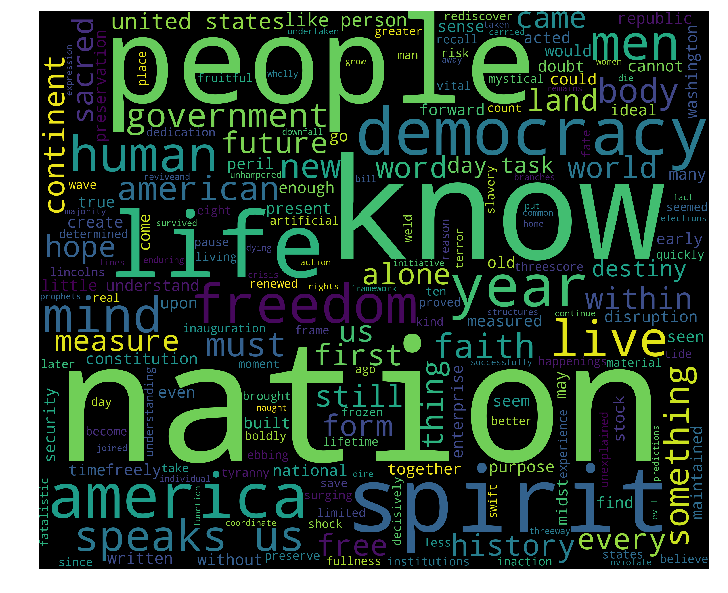

In [90]:
words = ' '.join(Franklin)

wordcloud = WordCloud(stopwords=stop,
                      background_color='black',
                      width=3000,
                      height=2500
                     ).generate(words)
plt.figure(1,figsize=(12, 12))
plt.imshow(wordcloud)
plt.axis('off')
plt.show()

### Wordcloud for John F. Kennedy's speech

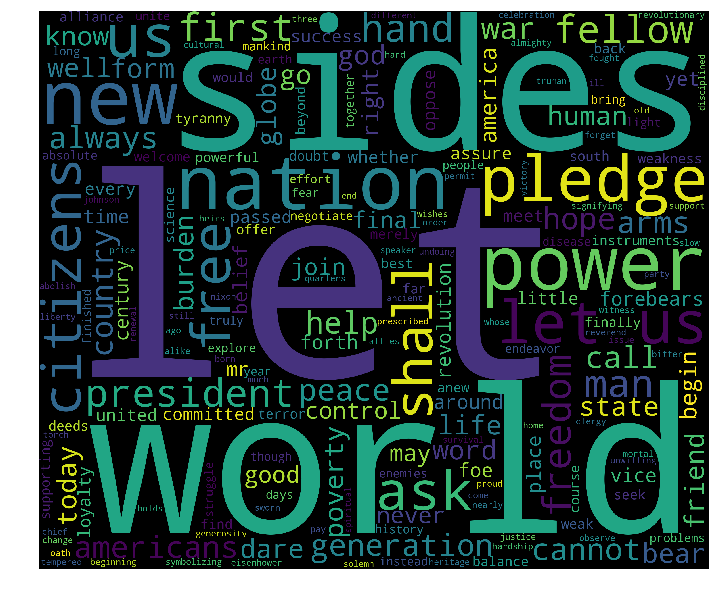

In [91]:
words1 = ' '.join(John)

wordcloud1 = WordCloud(stopwords=stop,
                      background_color='black',
                      width=3000,
                      height=2500
                     ).generate(words1)
plt.figure(1,figsize=(12, 12))
plt.imshow(wordcloud1)
plt.axis('off')
plt.show()

### Wordcloud for Richard Nixon's speech

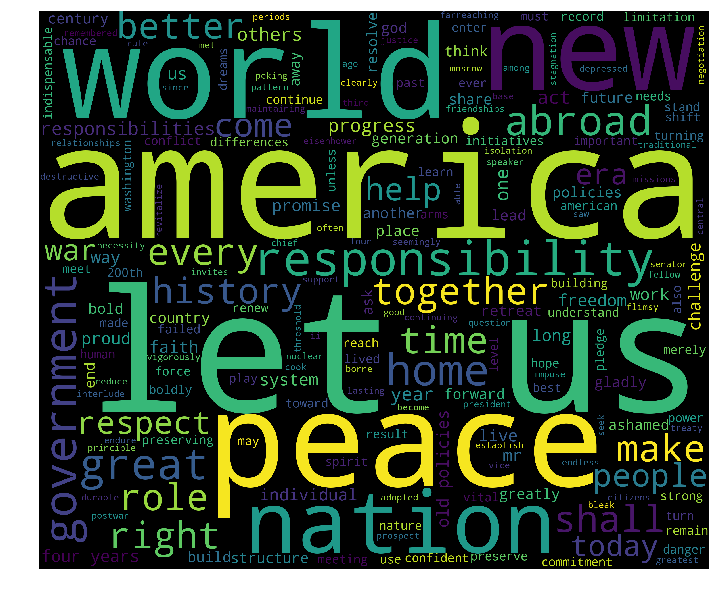

In [92]:
words2 = ' '.join(Richard)

wordcloud2 = WordCloud(stopwords=stop,
                      background_color='black',
                      width=3000,
                      height=2500
                     ).generate(words2)
plt.figure(1,figsize=(12, 12))
plt.imshow(wordcloud2)
plt.axis('off')
plt.show()